# Day 10 — Visual Exploratory Data Analysis (EDA)

## Objective
To analyse the image quality, class distribution and degradation patterns in the three supplied underwater datasets.

## Dataset Scope
The following datasets are analysed separately:
- DIATAquarium
- Aquatic Plant
- Well

## EDA Plan
1. Check basic dataset statistics.
2. Visualise representative raw images.
3. Analyse image brightness, contrast and resolution.
4. Analyse class distribution.
5. Identify common image degradation patterns.
6. Record hypotheses about difficult conditions.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

##  Dataset Access
The three supplied datasets are loaded from Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATASET_FOLDER = "/content/drive/MyDrive/Dataset (1)"
DATASETS = [
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"
]
for dataset in DATASETS:
    path = os.path.join(DATASET_FOLDER, dataset)
    print(dataset, "->", os.path.exists(path))

Mounted at /content/drive
DIATAquarium.v4i.yolov8 -> True
Aquatic Plant.v2i.yolov8 -> True
well.v8i.yolov8 -> True


##  Basic Dataset Statistics
The number of images and annotation files in each dataset split is checked before further analysis.

In [ ]:
for dataset in DATASETS:
    print("\nDataset:",dataset)
    for split in ["train","valid","test"]:
        image_path=os.path.join(DATASET_FOLDER,dataset,split,"images")
        label_path=os.path.join(DATASET_FOLDER,dataset,split,"labels")
        if not os.path.exists(image_path):
            print(split,": Not present")
            continue
        images=len(os.listdir(image_path))
        labels=len(os.listdir(label_path)) if os.path.exists(label_path) else 0
        print(split,":",images,"images,",labels,"labels")


Dataset: DIATAquarium.v4i.yolov8
train : 8121 images, 8121 labels
valid : 773 images, 773 labels
test : Not present

Dataset: Aquatic Plant.v2i.yolov8
train : 1892 images, 1879 labels
valid : 179 images, 179 labels
test : 89 images, 89 labels

Dataset: well.v8i.yolov8
train : 3795 images, 3780 labels
valid : 191 images, 191 labels
test : 184 images, 184 labels


## Representative Raw Images
A small sample of raw images from each dataset is displayed to observe image quality, objects and underwater visual conditions.

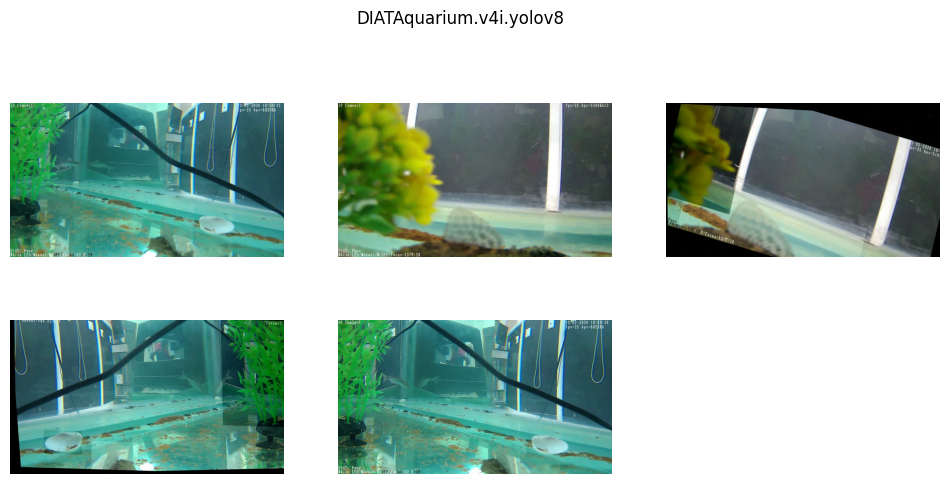

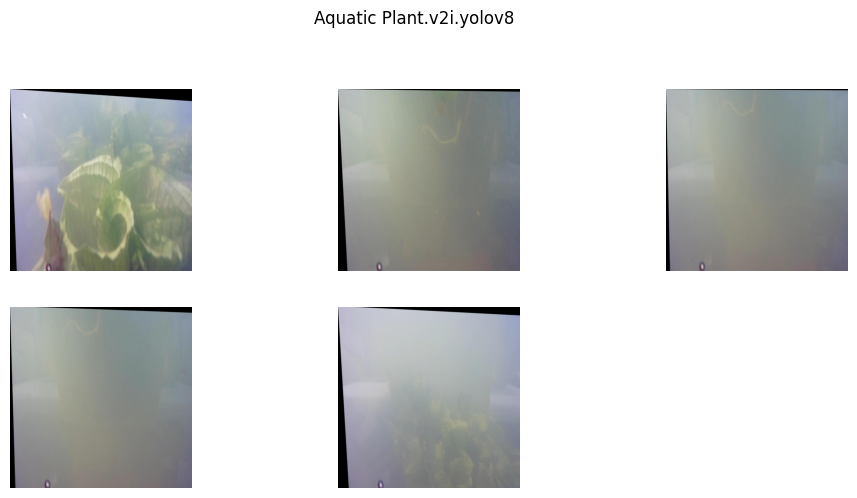

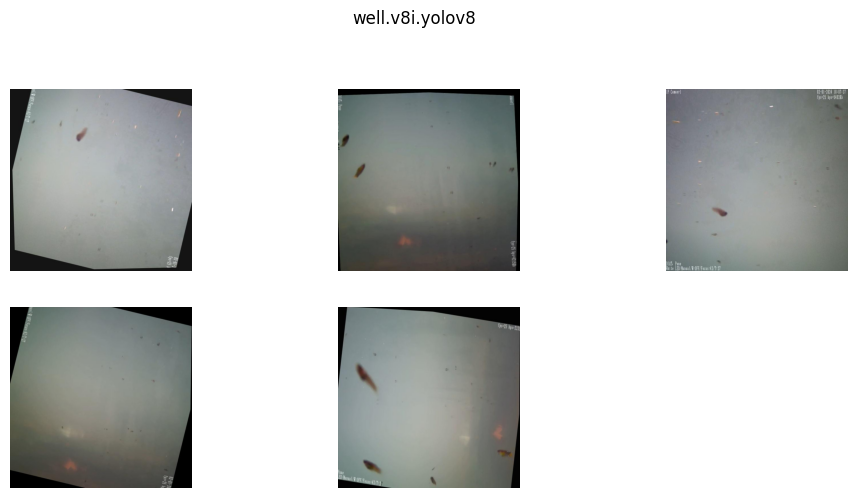

In [ ]:
for dataset in DATASETS:
    image_path=os.path.join(DATASET_FOLDER,dataset,"train","images")
    files=os.listdir(image_path)[:5]
    plt.figure(figsize=(12,8))
    for i,file in enumerate(files):
        img=cv2.imread(os.path.join(image_path,file))
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(dataset)
    plt.show()

## Image Quality Analysis
Brightness, contrast and image resolution are analysed to understand the visual quality and degradation patterns in the underwater images.

In [ ]:
for dataset in DATASETS:
    image_path=os.path.join(DATASET_FOLDER,dataset,"train","images")
    files=os.listdir(image_path)[:100]
    brightness=[]
    contrast=[]
    resolutions=[]
    for file in files:
        img=cv2.imread(os.path.join(image_path,file))
        gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
        brightness.append(np.mean(gray))
        contrast.append(np.std(gray))
        resolutions.append((img.shape[1],img.shape[0]))
    print("\nDataset:",dataset)
    print("Average brightness:",round(np.mean(brightness),2))
    print("Average contrast:",round(np.mean(contrast),2))
    print("Common resolution:",max(set(resolutions),key=resolutions.count))


Dataset: DIATAquarium.v4i.yolov8
Average brightness: 104.51
Average contrast: 49.1
Common resolution: (1920, 1080)

Dataset: Aquatic Plant.v2i.yolov8
Average brightness: 141.71
Average contrast: 31.98
Common resolution: (640, 640)

Dataset: well.v8i.yolov8
Average brightness: 125.52
Average contrast: 38.01
Common resolution: (640, 640)


DIATAquarium images are relatively darker and have higher contrast.
Aquatic Plant images are brighter and have lower contrast.
Well images have moderate brightness and contrast.

##Class Distribution
The number of objects in each class is analysed to identify class balance and imbalance in the three datasets.

In [ ]:
from collections import Counter

CLASS_NAMES={
    "DIATAquarium.v4i.yolov8":["Aquatic Plant","Camera","Conch-Shell","Fish","Fishes","Pluco","Shark","Temperature Sensor","Water-Pump","Water-filter","betta"],
    "Aquatic Plant.v2i.yolov8":["Aquatic_plant"],
    "well.v8i.yolov8":["Inlet-pipe","fishes","school-of-fish","stone"]
}
for dataset in DATASETS:
    counts=Counter()
    label_path=os.path.join(DATASET_FOLDER,dataset,"train","labels")
    for file in os.listdir(label_path):
        with open(os.path.join(label_path,file),"r") as f:
            for line in f:
                parts=line.strip().split()
                if len(parts)==5:
                    counts[int(parts[0])]+=1
    print("\nDataset:",dataset)
    for i,name in enumerate(CLASS_NAMES[dataset]):
        print(name,":",counts[i])


Dataset: DIATAquarium.v4i.yolov8
Aquatic Plant : 4329
Camera : 114
Conch-Shell : 1819
Fish : 2237
Fishes : 325
Pluco : 1058
Shark : 2429
Temperature Sensor : 428
Water-Pump : 1735
Water-filter : 171
betta : 1419

Dataset: Aquatic Plant.v2i.yolov8
Aquatic_plant : 1016

Dataset: well.v8i.yolov8
Inlet-pipe : 3
fishes : 45982
school-of-fish : 579
stone : 0


## Observation

Well has severe class imbalance, with most objects belonging to the fishes class.

## Class Distribution Graph
Bar graphs are used to visualise the number of objects in each class.

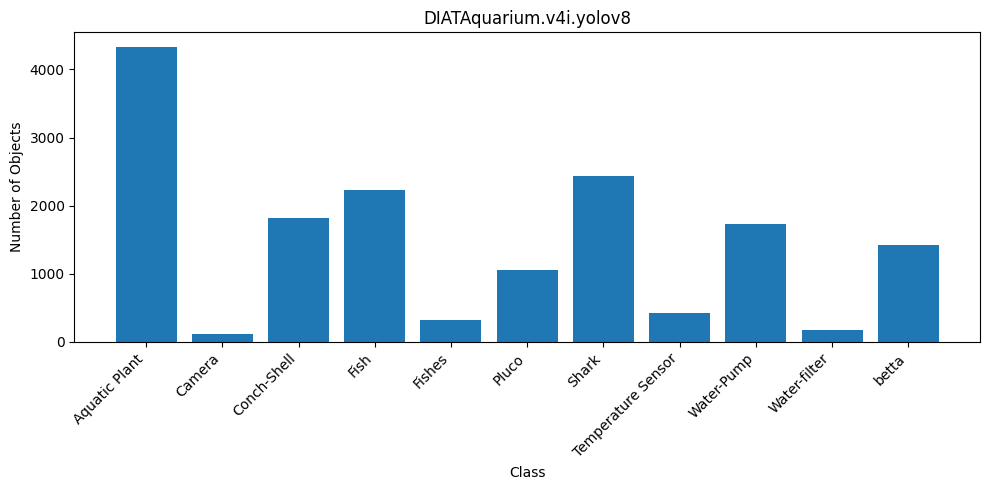

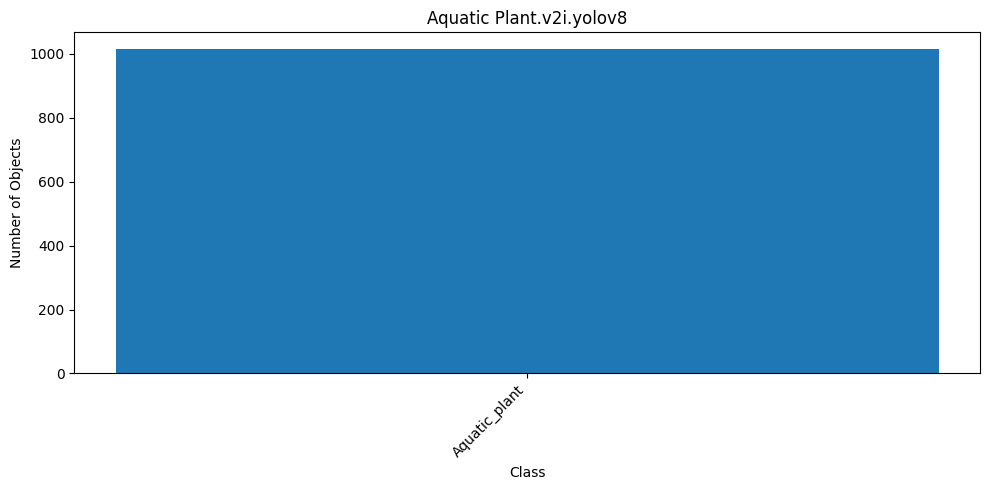

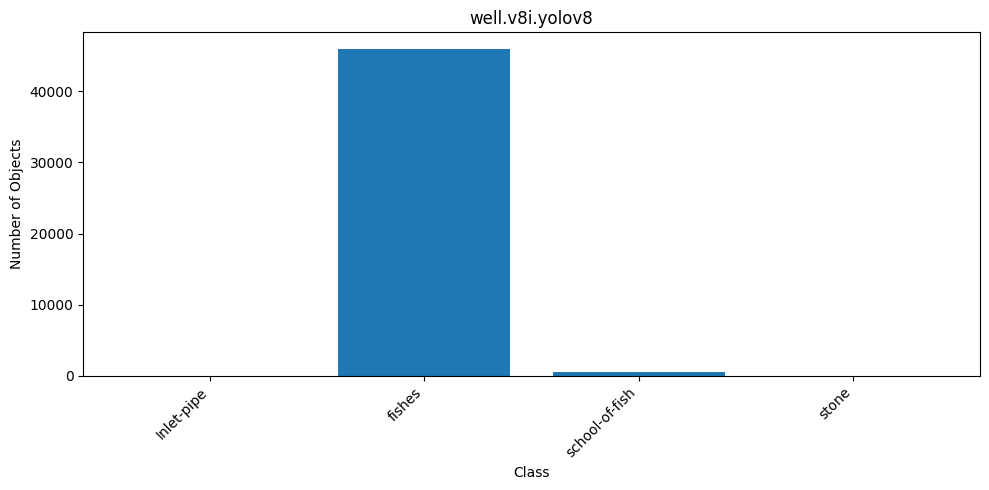

In [ ]:
for dataset in DATASETS:
    label_path=os.path.join(DATASET_FOLDER,dataset,"train","labels")
    counts=Counter()
    for file in os.listdir(label_path):
        with open(os.path.join(label_path,file),"r") as f:
            for line in f:
                parts=line.strip().split()
                if len(parts)==5:
                    counts[int(parts[0])]+=1

    names=CLASS_NAMES[dataset]
    values=[counts[i] for i in range(len(names))]
    plt.figure(figsize=(10,5))
    plt.bar(names,values)
    plt.title(dataset)
    plt.xlabel("Class")
    plt.ylabel("Number of Objects")
    plt.xticks(rotation=45,ha="right")
    plt.tight_layout()
    plt.show()

##Image Degradation Analysis
Common underwater image degradation patterns are identified from the sampled images.

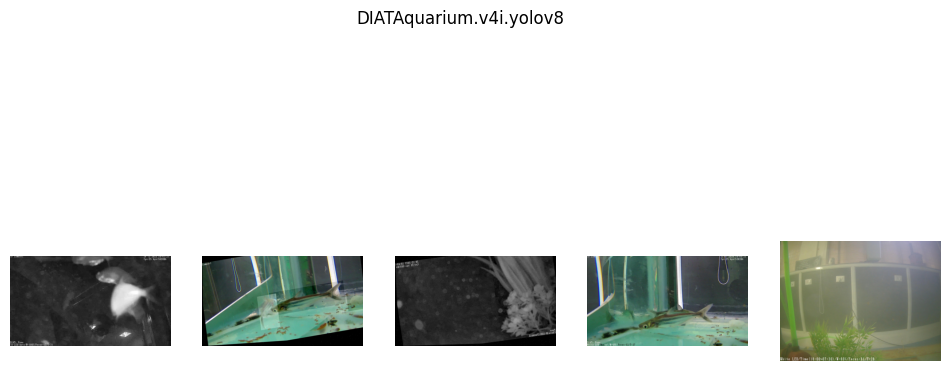

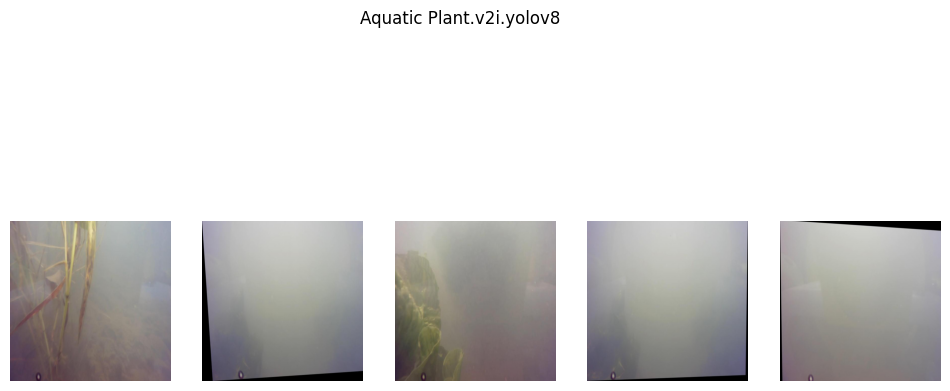

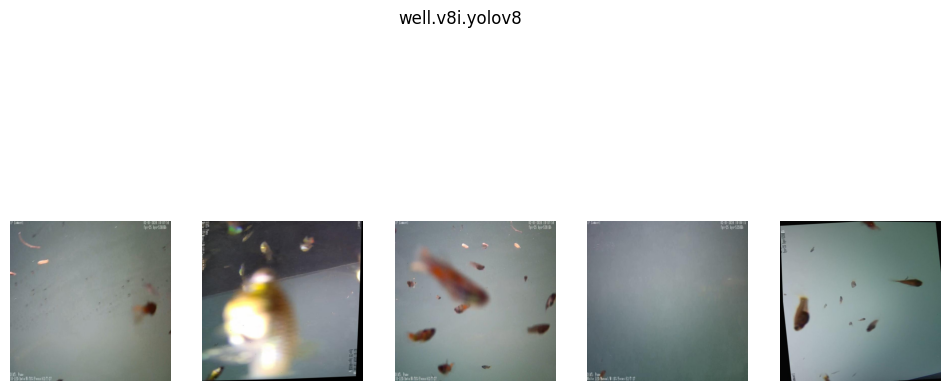

In [ ]:
import random
for dataset in DATASETS:
    image_path=os.path.join(DATASET_FOLDER,dataset,"train","images")
    files=os.listdir(image_path)
    files=random.sample(files,min(5,len(files)))

    plt.figure(figsize=(12,6))
    for i,file in enumerate(files):
        img=cv2.imread(os.path.join(image_path,file))
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(dataset)
    plt.show()

## Observation
The sampled images show haze, low visibility and low contrast.
Some images also contain colour variation and dark border regions.
These conditions may make object detection more difficult.

## Difficult Conditions Hypothesis
Haze, low visibility, low contrast and colour distortion may make underwater objects harder to detect.
Image enhancement may improve object visibility and may affect detection performance.